In [1]:
import pandas as pd

In [4]:
df=pd.DataFrame({"이름":['tome','jack','juli'],
                "색":['red','blue','blue'],
                "순위":[5,3,2]})
df.columns

Index(['이름', '색', '순위'], dtype='str')

In [5]:
df['이름']

0    tome
1    jack
2    juli
Name: 이름, dtype: str

In [6]:
df[['이름']]

,이름
0,tome
1,jack
2,juli


In [7]:
df[['이름','순위']]

,이름,순위
0,tome,5
1,jack,3
2,juli,2


In [8]:
df['순위']

0    5
1    3
2    2
Name: 순위, dtype: int64

In [9]:
df['순위']<3

0    False
1    False
2     True
Name: 순위, dtype: bool

In [11]:
df[df['순위']<3]

,이름,색,순위
2,juli,blue,2


In [12]:
# 색이 red인 데이터만 데이터프레임으로 출력
df[df['색']=='red']

,이름,색,순위
0,tome,red,5


In [16]:
df[(df['순위']>2) &(df['순위']<5)]

,이름,색,순위
1,jack,blue,3


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('C:/a/run/online_retail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [21]:
df['CustomerID'].isna().sum()

np.int64(135080)

In [27]:
# 불리언인덱싱 기법 (True인 행만 남김) -> null값들은 버림
# 값이 있는 행만 df에 재할당
df=df[df['CustomerID'].notnull()]

In [28]:
df['CustomerID'].isna().sum()

np.int64(0)

In [30]:
#(df['Quantity']>0)&(df['UnitPrice'>0) 가 true 인 행만 남겨 df에 저장
df=df[(df['Quantity']>0)&(df['UnitPrice']>0)]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [31]:
print((df['Quantity']<=0).sum())
print((df['UnitPrice']<=0).sum())

0
0


In [36]:
# 고객아이디별로 묶어서 해당 고객이 사용한 송장번호의 개수(고유한 개수)
# 뽑으면 고객별 구매한 빈도 수 추출할 수 있다.
# reset_index() : 그룹화 결과를 다시 DataFrame으로 변환
frequency_df=df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.columns=['CustomerID','Frequency']
frequency_df

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4333,18280.0,1
4334,18281.0,1
4335,18282.0,2
4336,18283.0,16


In [50]:
# data={'가입일':['2026-04-09','2026-04-08']}
# df1=pd.DataFrame(data)

# df1['가입일'] = pd.to_datetime(df1['가입일'])
# df1['가입년도']=df1['가입일'].dt.year
# print(df1['가입년도'])

# df1['가입월']=df1['가입일'].dt.month
# print(df1['가입월'])

# df1['가입일']=df1['가입일'].dt.day
# print(df1['가입일'])

In [51]:
# 문자열 -> 날짜형식으로 변환
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate']

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 397884, dtype: datetime64[us]

In [52]:
# 가장 최근에 주문한 날짜
latest=df['InvoiceDate'].max()
latest

Timestamp('2011-12-09 12:50:00')

In [57]:
# 고객별로 주문일의 최대값 출력 => 데이터프레임형태
recency_df=df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

# 고객별로 며칠전에 구매했는지 (가장 최근 주문 날짜 기준으로)
recency_df['Recency']=(latest-recency_df['InvoiceDate']).dt.days
recency_df

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309
...,...,...,...
4333,18280.0,2011-03-07 09:52:00,277
4334,18281.0,2011-06-12 10:53:00,180
4335,18282.0,2011-12-02 11:43:00,7
4336,18283.0,2011-12-06 12:02:00,3


In [60]:
# InvoiceDate 뜨는 거 불필요해서 컬럼 제거함
recency_df.drop('InvoiceDate', axis=1, inplace=True)
recency_df

KeyError: "['InvoiceDate'] not found in axis"

In [64]:
recency_df['Recency'].isna().sum()

np.int64(0)

In [67]:
# 단가*수량 => TotalPrice컬럼 생성
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df

# 고객별 아이디로 그룹화 해서 sum()
monetary_df=df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_df

,CustomerID,TotalPrice
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


In [68]:
# R, F, M 결합
# R : 며칠 전에 구매했냐
# F : 몇 번 구매했냐
# M : 얼마나 썼냐

In [69]:
rfm_df=recency_df.merge(frequency_df, on='CustomerID').merge(monetary_df, on='CustomerID')
rfm_df

,CustomerID,Recency,Frequency,TotalPrice
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40
...,...,...,...,...
4333,18280.0,277,1,180.60
4334,18281.0,180,1,80.82
4335,18282.0,7,2,178.05
4336,18283.0,3,16,2094.88


In [72]:
# 군집 알고리즘(클러스터링)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [74]:
X=rfm_df[['Recency','Frequency','TotalPrice']]
X

,Recency,Frequency,TotalPrice
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40
...,...,...,...
4333,277,1,180.60
4334,180,1,80.82
4335,7,2,178.05
4336,3,16,2094.88


In [76]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

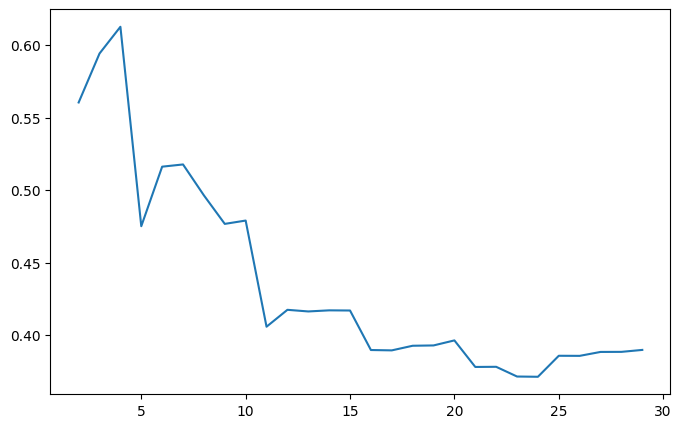

In [83]:
# 클러스터링 개수 범위 지정함
# 2-29 까지 돌려보고 어느 k가 가장 좋은지 확인
k_range=range(2,30)
# 각 k값의 점수를 담을 리스트
silhouette_grade=[]

# i개 클러스터로 군집화/데이터 학습시키고 각 데이터의 클러스터 라벨 예측
for i in k_range:
    kmeans=KMeans(n_clusters=i, random_state=1)
    # 모델학습+클러스터할당예측 한번에 수행
    labels=kmeans.fit_predict(X_scaled)
    grade=silhouette_score(X_scaled, labels)
    silhouette_grade.append(grade)

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_grade)
plt.show()

# 실루엣 계수(응집도/분리도) 고려/ elbow(응집도 고려) - 주관적
# elbow로 뽑고 그 이후에 실루엣 계수 뽑는다


In [84]:
silhouette_grade

[0.56042333754011,
 0.5941879366550106,
 0.6126112251227308,
 0.47511778751953077,
 0.516164881940495,
 0.5176982073786867,
 0.49637819657194976,
 0.4767181119068522,
 0.47901484329517086,
 0.40582912943587557,
 0.41747869794796,
 0.4163544730443067,
 0.4171103771042279,
 0.4170010435526701,
 0.38975950281738475,
 0.38951404625779384,
 0.39270156925287014,
 0.3929202033752237,
 0.39639158163617655,
 0.37808618068654337,
 0.3781913952171706,
 0.3714888754956686,
 0.37131372878217483,
 0.3857965736306954,
 0.38573670857924064,
 0.3884415731879478,
 0.3884918776307378,
 0.38983242678873364]

In [90]:
kmeans=KMeans(n_clusters=4, random_state=1)
# 4개로 클러스터링 했을때, 각 데이터가 어떤 클러스터에 속하는지 라벨 뽑음

rfm_df['ClusterLabel']=kmeans.fit_predict(X_scaled)
rfm_df

# RFM 데이터 기준으로 고객을 4개 그룹으로 분류해서 각 고객이 속한 클러스터 번호를 출력해봄

,CustomerID,Recency,Frequency,TotalPrice,ClusterLabel
0,12346.0,325,1,77183.60,2
1,12347.0,1,7,4310.00,0
2,12348.0,74,4,1797.24,0
3,12349.0,18,1,1757.55,0
4,12350.0,309,1,334.40,1
...,...,...,...,...,...
4333,18280.0,277,1,180.60,1
4334,18281.0,180,1,80.82,1
4335,18282.0,7,2,178.05,0
4336,18283.0,3,16,2094.88,0


In [92]:
clkuster1=rfm_df.groupby('ClusterLabel').agg({
    'Recency':'mean', # 각 클러스터별 Recency 평균
    'Frequency':'mean',
    'TotalPrice':'mean',
    'ClusterLabel':'count'
})
clkuster1

,Recency,Frequency,TotalPrice,ClusterLabel
ClusterLabel,,,,
0,41.412472,4.136752,1563.782438,3159
1,246.312268,1.552974,556.665949,1076
2,12.406250,34.739583,21702.508229,96
3,5.714286,65.428571,184143.690000,7


In [93]:
pip install plotly

     ---------------------------------------- 9.9/9.9 MB 33.3 MB/s eta 0:00:00
     ------------------------------------- 447.0/447.0 kB 29.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
import plotly.express as pe

In [95]:
fig=pe.scatter_3d(
    rfm_df, x='Recency', y='Frequency', z='TotalPrice', color='ClusterLabel',
    labels={'Recency':'Recency','Frequency':'Frequency','TotalPrice':'TotalPrice'})
fig.write_html("C:/a/run/3d.html")

In [96]:
# DBSCAN(밀도기반 클러스터링) : 밀집구역을 클래스터 찾고 희소 지역은 노이즈로 처리
dbscan=DBSCAN()
# 학습시키면서 각 데이터에 클러스터 라벨 부여
dbscan_labels=dbscan.fit_predict(X_scaled)
dbscan_labels

array([-1,  0,  0, ...,  0,  0,  0], shape=(4338,))

In [98]:
# 노이즈 제거 후 유효한 클러스터 개수 확인할거임
drop_noise=dbscan_labels[dbscan_labels!=-1]
unique_label=set(drop_noise)
unique_label

{np.int64(0)}

In [127]:
# 하이퍼 파라미터 튜닝(eps, min_samples)
dbscan=DBSCAN(eps=0.4, min_samples=4)
dbscan_labels=dbscan.fit_predict(X_scaled)
dbscan_labels

array([-1,  0,  0, ...,  0,  0,  0], shape=(4338,))

In [130]:
drop_noise=dbscan_labels[dbscan_labels!=-1]
unique_label=set(drop_noise)

# 노이즈 제외된 데이터만 사용
if len(unique_label)>=2:
    dbscan_sil=silhouette_score(X_scaled[dbscan_labels!=-1], drop_noise)
    dbscan_sil